1. data exploration

1.1 dataset overview

In [1]:
import pandas as pd

train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

display(train.head())
display(test.head())

,geological_era,weather_pattern,region,aptitude_score,performance_score,stability_index,personal_interest,load_ratio,brew_preference,instrument,species,index_weight,mineral_type,activity_duration,composite_rank,label
0,Triassic,Heatwave,Texas,325.58,34.95,1.503,Foraging,23.878,Espresso,Dulcimer,Lynx,8.63,Marble,77.98,2.093,no
1,Triassic,Monsoon,Texas,333.63,256.50,3.283,Falconry,28.617,Espresso,Cello,Bison,14.22,Opal,95.76,3.028,no
2,Triassic,Monsoon,Texas,503.96,385.00,3.676,Astronomy,22.582,Espresso,Cello,Lynx,11.04,Diamond,114.03,4.564,yes
3,Triassic,Heatwave,Texas,404.61,156.44,2.812,Calligraphy,28.002,Latte,Oboe,Lynx,15.64,Sapphire,113.58,3.053,no
4,Triassic,Heatwave,Texas,358.89,144.05,2.735,Beekeeping,22.062,Espresso,Oboe,Lynx,10.99,Granite,79.40,2.730,no


,geological_era,weather_pattern,region,aptitude_score,performance_score,stability_index,personal_interest,load_ratio,brew_preference,instrument,species,index_weight,mineral_type,activity_duration,composite_rank,label
0,Triassic,Heatwave,Texas,307.75,76.09,2.153,Beekeeping,27.126,Espresso,Oboe,Lynx,9.44,Marble,83.75,2.151,no
1,Triassic,Blizzard,Texas,304.86,176.77,2.927,Beekeeping,26.398,Espresso,Theremin,Lynx,2.28,Marble,80.74,2.536,no
2,Triassic,Monsoon,Texas,325.50,479.93,3.892,Calligraphy,34.717,Espresso,Cello,Heron,6.09,Marble,113.35,3.873,no
3,Triassic,Monsoon,Texas,336.46,340.57,3.557,Other,25.502,Espresso,Cello,Lynx,7.93,Opal,86.06,3.381,no
4,Triassic,Monsoon,Texas,307.02,510.19,3.952,Falconry,26.268,Espresso,Cello,Lynx,14.12,Marble,80.91,3.883,no


In [2]:
print("Training set shape:", train.shape)
print("Test set shape:", test.shape)

Training set shape: (31112, 16)
Test set shape: (13334, 16)


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31112 entries, 0 to 31111
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   geological_era     31110 non-null  object 
 1   weather_pattern    31109 non-null  object 
 2   region             31108 non-null  object 
 3   aptitude_score     31108 non-null  float64
 4   performance_score  31110 non-null  float64
 5   stability_index    31110 non-null  float64
 6   personal_interest  31106 non-null  object 
 7   load_ratio         31110 non-null  float64
 8   brew_preference    31105 non-null  object 
 9   instrument         31109 non-null  object 
 10  species            31109 non-null  object 
 11  index_weight       31109 non-null  float64
 12  mineral_type       31109 non-null  object 
 13  activity_duration  31110 non-null  float64
 14  composite_rank     31111 non-null  float64
 15  label              31109 non-null  object 
dtypes: float64(7), object(

1.2 unique values

In [4]:
print(train.nunique())
print(train["label"].unique())

geological_era           5
weather_pattern          7
region                  21
aptitude_score       15148
performance_score    24418
stability_index       3788
personal_interest       11
load_ratio           18799
brew_preference          2
instrument               6
species                  7
index_weight          3595
mineral_type            16
activity_duration     9657
composite_rank        4213
label                    2
dtype: int64
['no' 'yes' nan]


1.3 missing values and duplicates

In [5]:
print("Missing values in training set:")
print(train.isnull().sum())

print("\nMissing values in test set:")
print(test.isnull().sum())

Missing values in training set:
geological_era       2
weather_pattern      3
region               4
aptitude_score       4
performance_score    2
stability_index      2
personal_interest    6
load_ratio           2
brew_preference      7
instrument           3
species              3
index_weight         3
mineral_type         3
activity_duration    2
composite_rank       1
label                3
dtype: int64

Missing values in test set:
geological_era       2
weather_pattern      0
region               1
aptitude_score       1
performance_score    0
stability_index      1
personal_interest    1
load_ratio           1
brew_preference      3
instrument           2
species              2
index_weight         1
mineral_type         0
activity_duration    1
composite_rank       4
label                1
dtype: int64


In [6]:
print("Duplicated rows in training set:", train.duplicated().sum())
print("Duplicated rows in test set:", test.duplicated().sum())

Duplicated rows in training set: 0
Duplicated rows in test set: 0


1.4 descriptive statistics

In [7]:
display(train.describe())
display(train.describe(include="object"))

,aptitude_score,performance_score,stability_index,load_ratio,index_weight,activity_duration,composite_rank
count,31108.00000,31110.000000,31110.000000,31110.000000,31109.000000,31110.000000,31111.000000
mean,342.13448,296.492726,3.156426,24.422677,12.721826,80.360618,3.238771
std,68.92509,187.620357,0.849307,9.920133,7.747198,25.515080,0.869784
min,90.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589000
25%,310.59750,146.572500,2.751000,19.272000,7.520000,72.740000,2.591000
50%,333.51500,275.385000,3.351000,23.689000,11.730000,80.330000,3.199000
75%,402.56250,420.170000,3.761750,27.656750,16.230000,90.257500,3.838000
max,510.00000,1010.000000,4.625000,143.717000,99.620000,205.000000,6.876000


,geological_era,weather_pattern,region,personal_interest,brew_preference,instrument,species,mineral_type,label
count,31110,31109,31108,31106,31105,31109,31109,31109,31109
unique,5,7,21,11,2,6,7,16,2
top,Triassic,Monsoon,Texas,Astronomy,Espresso,Cello,Lynx,Marble,no
freq,26642,14274,27915,3965,20777,12573,21723,10077,23645


1.5 class distribution

In [8]:
print(train["label"].value_counts())
print(train["label"].value_counts(normalize=True) * 100)

label
no     23645
yes     7464
Name: count, dtype: int64
label
no     76.006943
yes    23.993057
Name: proportion, dtype: float64


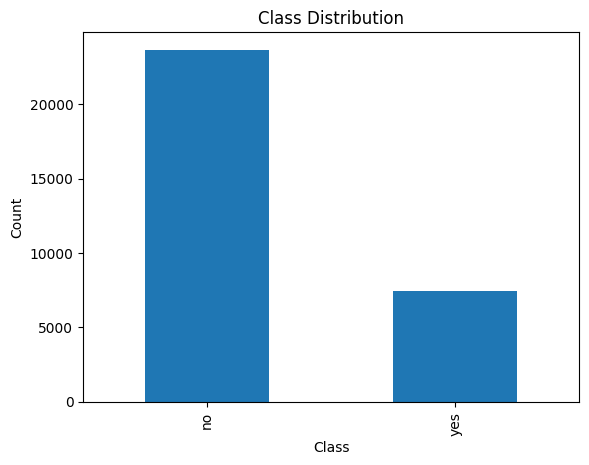

In [9]:
import matplotlib.pyplot as plt

train["label"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

1.6 outlier exploration

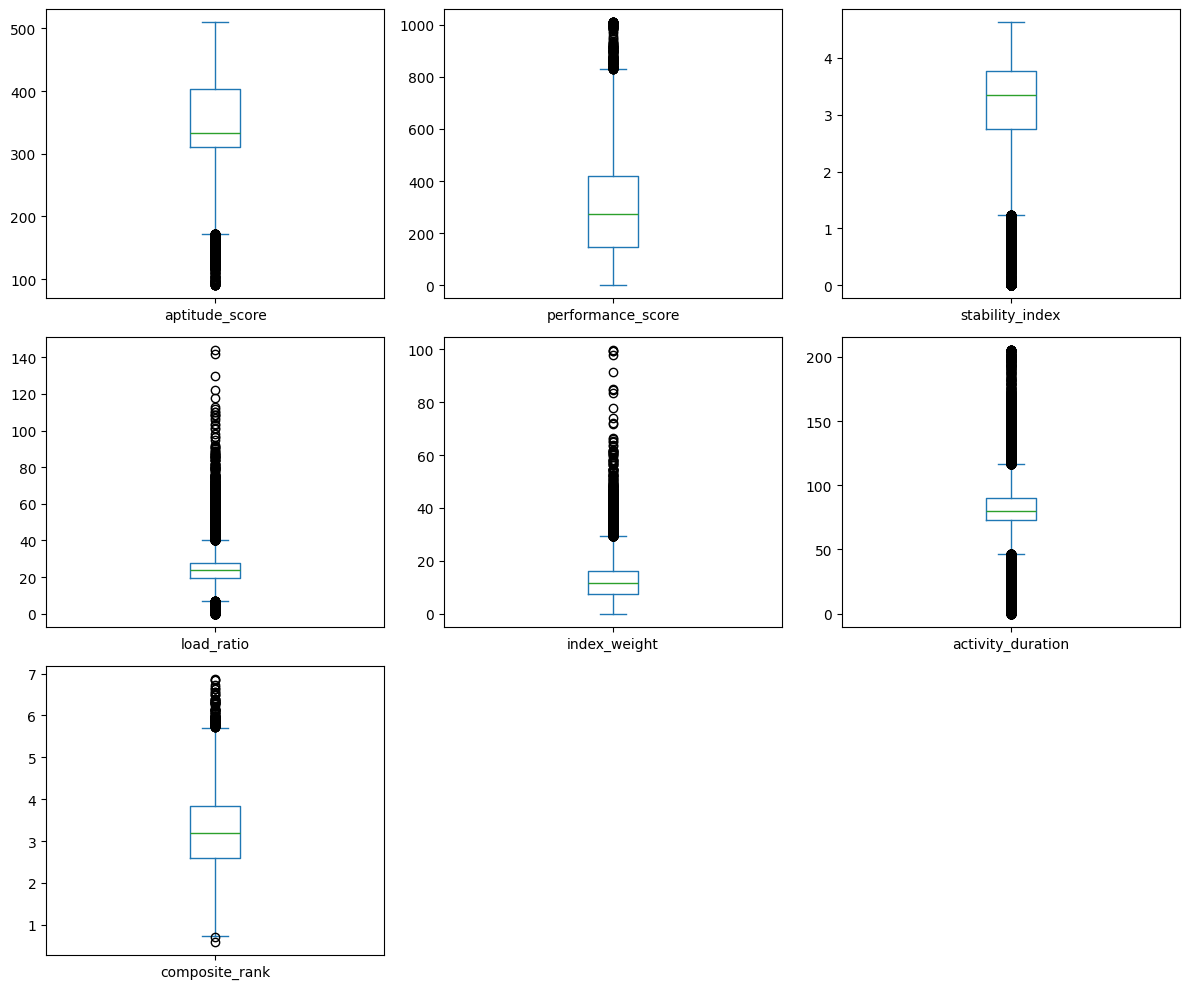

In [10]:
numerical_features = train.select_dtypes(include=["number"]).columns

train[numerical_features].plot(
    kind="box",
    subplots=True,
    layout=(3, 3),
    figsize=(12, 10)
)

plt.tight_layout()
plt.show()

2. data cleaning

2.1 handle missing target values

In [11]:
print("Missing labels in training set:", train["label"].isnull().sum())
print("Missing labels in test set:", test["label"].isnull().sum())

train = train.dropna(subset=["label"])
test = test.dropna(subset=["label"])

print("Missing labels in training set:", train["label"].isnull().sum())
print("Missing labels in test set:", test["label"].isnull().sum())

Missing labels in training set: 3
Missing labels in test set: 1
Missing labels in training set: 0
Missing labels in test set: 0


2.2 handle missing numerical features

In [12]:
numerical_features = train.select_dtypes(include=["number"]).columns
print(numerical_features)

for column in numerical_features:
    median_value = train[column].median()
    train[column] = train[column].fillna(median_value)
    test[column] = test[column].fillna(median_value)

Index(['aptitude_score', 'performance_score', 'stability_index', 'load_ratio',
       'index_weight', 'activity_duration', 'composite_rank'],
      dtype='object')


2.3 handle missing categorical features

In [13]:
categorical_features = train.select_dtypes(include=["object"]).columns.drop("label")
print(categorical_features)

for column in categorical_features:
    mode_value = train[column].mode()[0]
    train[column] = train[column].fillna(mode_value)
    test[column] = test[column].fillna(mode_value)

Index(['geological_era', 'weather_pattern', 'region', 'personal_interest',
       'brew_preference', 'instrument', 'species', 'mineral_type'],
      dtype='object')


2.4 verify missing values

In [14]:
print("Missing values in training set:")
print(train.isnull().sum())

print("\nMissing values in test set:")
print(test.isnull().sum())

Missing values in training set:
geological_era       0
weather_pattern      0
region               0
aptitude_score       0
performance_score    0
stability_index      0
personal_interest    0
load_ratio           0
brew_preference      0
instrument           0
species              0
index_weight         0
mineral_type         0
activity_duration    0
composite_rank       0
label                0
dtype: int64

Missing values in test set:
geological_era       0
weather_pattern      0
region               0
aptitude_score       0
performance_score    0
stability_index      0
personal_interest    0
load_ratio           0
brew_preference      0
instrument           0
species              0
index_weight         0
mineral_type         0
activity_duration    0
composite_rank       0
label                0
dtype: int64


2.5 potential outliers
Potential outliers were observed in some numerical features during data exploration. However, there was insufficient evidence to determine that these extreme values were data errors. Therefore, the potential outliers were retained to avoid removing 
potentially valid observations.

3. feature preprocessing

3.1 separate features and target

In [15]:
X_train = train.drop(columns=["label"])
y_train = train["label"]

X_test = test.drop(columns=["label"])
y_test = test["label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (31109, 15)
X_test shape: (13333, 15)
y_train shape: (31109,)
y_test shape: (13333,)


3.2 Identify Numerical and Categorical Features

In [16]:
numerical_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['aptitude_score', 'performance_score', 'stability_index', 'load_ratio',
       'index_weight', 'activity_duration', 'composite_rank'],
      dtype='object')

Categorical features:
Index(['geological_era', 'weather_pattern', 'region', 'personal_interest',
       'brew_preference', 'instrument', 'species', 'mineral_type'],
      dtype='object')


3.3 categorical encoding

In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

print("Encoded training categorical shape:", X_train_cat.shape)
print("Encoded test categorical shape:", X_test_cat.shape)

Encoded training categorical shape: (31109, 75)
Encoded test categorical shape: (13333, 75)


3.4 numerical feature scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num_scaled = scaler.transform(
    X_test[numerical_features]
)

3.5 Prepare Data for KNN

In [19]:
import numpy as np

X_train_knn = np.hstack([
    X_train_num_scaled,
    X_train_cat
])

X_test_knn = np.hstack([
    X_test_num_scaled,
    X_test_cat
])

print("KNN training shape:", X_train_knn.shape)
print("KNN test shape:", X_test_knn.shape)

KNN training shape: (31109, 82)
KNN test shape: (13333, 82)


3.6 Prepare Data for Decision Tree

In [20]:
X_train_dt = np.hstack([
    X_train[numerical_features].values,
    X_train_cat
])

X_test_dt = np.hstack([
    X_test[numerical_features].values,
    X_test_cat
])

print("Decision Tree training shape:", X_train_dt.shape)
print("Decision Tree test shape:", X_test_dt.shape)

Decision Tree training shape: (31109, 82)
Decision Tree test shape: (13333, 82)


3.7 feature selection
All available predictor variables were retained because there was no sufficient evidence at this stage to justify removing specific features. No additional feature engineering was performed in order to keep the preprocessing procedure simple and interpretable.

4. model training

4.1 KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Encode target labels for KNN
y_train_knn = y_train.map({"no": 0, "yes": 1})

knn = KNeighborsClassifier()

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid={
        "n_neighbors": [3, 5, 7, 9, 11],
        "metric": ["euclidean", "manhattan"]
    },
    cv=5,
    scoring=make_scorer(f1_score, pos_label=1),
    error_score="raise"
)

knn_grid.fit(X_train_knn, y_train_knn)

print("Best parameters:", knn_grid.best_params_)
print("Best CV F1-score:", knn_grid.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 11}
Best CV F1-score: 0.6266909030845573


4.2 decision tree

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

dt = DecisionTreeClassifier(
    random_state=42
)

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid={
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },
    cv=5,
    scoring=make_scorer(f1_score, pos_label="yes"),
    error_score="raise"
)

dt_grid.fit(X_train_dt, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV F1-score:", dt_grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV F1-score: 0.5963216436527252


4.3 obtain the best models

In [23]:
best_knn = knn_grid.best_estimator_
best_dt = dt_grid.best_estimator_

print("Best KNN model:")
print(best_knn)

print("\nBest Decision Tree model:")
print(best_dt)

Best KNN model:
KNeighborsClassifier(metric='euclidean', n_neighbors=11)

Best Decision Tree model:
DecisionTreeClassifier(max_depth=10, min_samples_leaf=2, random_state=42)


5. evaluation and comparison

5.1 make predictions on the test set

In [24]:
# Prepare test labels for KNN
y_test_knn = y_test.map({"no": 0, "yes": 1})

# Get the best models from GridSearchCV
best_knn = knn_grid.best_estimator_
best_dt = dt_grid.best_estimator_

# Make predictions
y_pred_knn = best_knn.predict(X_test_knn)
y_pred_dt = best_dt.predict(X_test_dt)

print("KNN predictions:", y_pred_knn[:10])
print("Decision Tree predictions:", y_pred_dt[:10])

KNN predictions: [0 0 0 1 0 0 0 0 0 0]
Decision Tree predictions: ['no' 'no' 'no' 'yes' 'no' 'no' 'no' 'no' 'no' 'no']


5.2 evaluate the two models

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# KNN
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)
knn_precision = precision_score(y_test_knn, y_pred_knn, pos_label=1)
knn_recall = recall_score(y_test_knn, y_pred_knn, pos_label=1)
knn_f1 = f1_score(y_test_knn, y_pred_knn, pos_label=1)

# Decision Tree
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, pos_label="yes")
dt_recall = recall_score(y_test, y_pred_dt, pos_label="yes")
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="yes")

print("KNN")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

print("\nDecision Tree")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

KNN
Accuracy: 0.8289207230180754
Precision: 0.651107325383305
Recall: 0.603219696969697
F1-score: 0.6262493855480911

Decision Tree
Accuracy: 0.8257706442661067
Precision: 0.6434634974533107
Recall: 0.5981691919191919
F1-score: 0.6199901848519549


5.3 confusion matrices

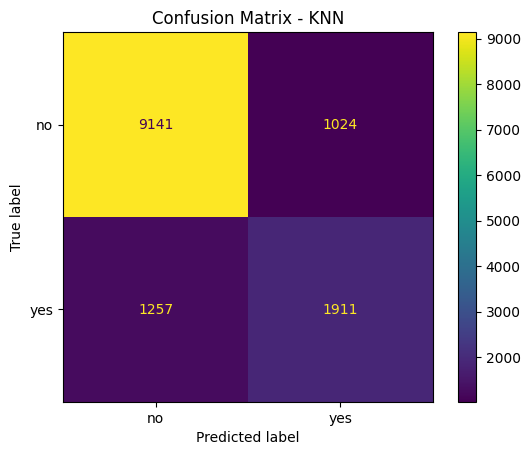

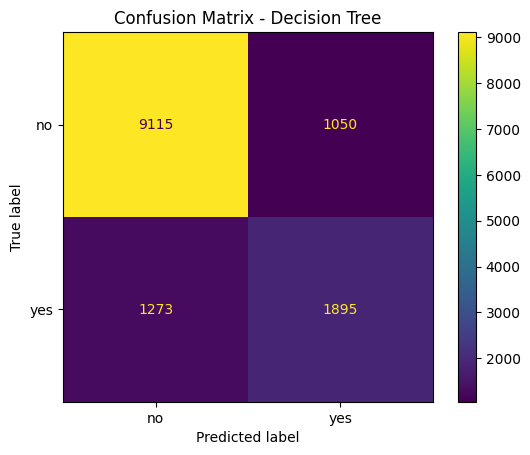

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# KNN
cm_knn = confusion_matrix(y_test_knn, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["no", "yes"]
)

disp_knn.plot()
plt.title("Confusion Matrix - KNN")
plt.show()


# Decision Tree
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["no", "yes"]
)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["no", "yes"]
)

disp_dt.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

5.4 compare the two models

In [27]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Accuracy": [knn_accuracy, dt_accuracy],
    "Precision": [knn_precision, dt_precision],
    "Recall": [knn_recall, dt_recall],
    "F1-score": [knn_f1, dt_f1]
})

print(comparison.round(4))

           Model  Accuracy  Precision  Recall  F1-score
0            KNN    0.8289     0.6511  0.6032    0.6262
1  Decision Tree    0.8258     0.6435  0.5982    0.6200
